<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('retailboost_customers.csv')

In [ ]:
display(df.head())

,customer_id,edad,ingresos_mensuales,region,frecuencia_visitas,compró
0,1,56,3697.72,Norte,2,1
1,2,69,2825.97,Este,15,0
2,3,46,784.50,Este,14,0
3,4,32,1612.61,Oeste,11,0
4,5,60,3013.53,Este,3,0


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    int64  
 1   edad                500 non-null    int64  
 2   ingresos_mensuales  485 non-null    float64
 3   region              485 non-null    object 
 4   frecuencia_visitas  500 non-null    int64  
 5   compró              500 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 23.6+ KB
None


In [5]:
display(df.describe())

,customer_id,edad,ingresos_mensuales,frecuencia_visitas,compró
count,500.000000,500.000000,485.000000,500.000000,500.000000
mean,250.500000,44.220000,1972.529052,9.928000,0.388000
std,144.481833,15.036082,797.388756,5.430082,0.487783
min,1.000000,18.000000,-593.010000,1.000000,0.000000
25%,125.750000,32.000000,1425.240000,5.000000,0.000000
50%,250.500000,45.000000,1973.840000,10.000000,0.000000
75%,375.250000,57.000000,2502.680000,15.000000,1.000000
max,500.000000,69.000000,4463.100000,19.000000,1.000000


In [8]:
# 1. Arregla el ingreso negativo
df.loc[df['ingresos_mensuales'] < 0, 'ingresos_mensuales'] = np.nan

# 2. Imputa nulos en ingresos_mensuales
mediana_ingresos = df['ingresos_mensuales'].median()
df['ingresos_mensuales'] = df['ingresos_mensuales'].fillna(mediana_ingresos)

# 3. Imputa nulos en region
moda_region = df['region'].mode()[0]
df['region'] = df['region'].fillna(moda_region)

# 4. Verifica que todo haya quedado limpio
print("--- Nulos restantes ---")
print(df.isnull().sum())
print("\n--- Nuevo ingreso mínimo ---")
print(df['ingresos_mensuales'].min())

--- Nulos restantes ---
customer_id           0
edad                  0
ingresos_mensuales    0
region                0
frecuencia_visitas    0
compró                0
dtype: int64

--- Nuevo ingreso mínimo ---
22.68


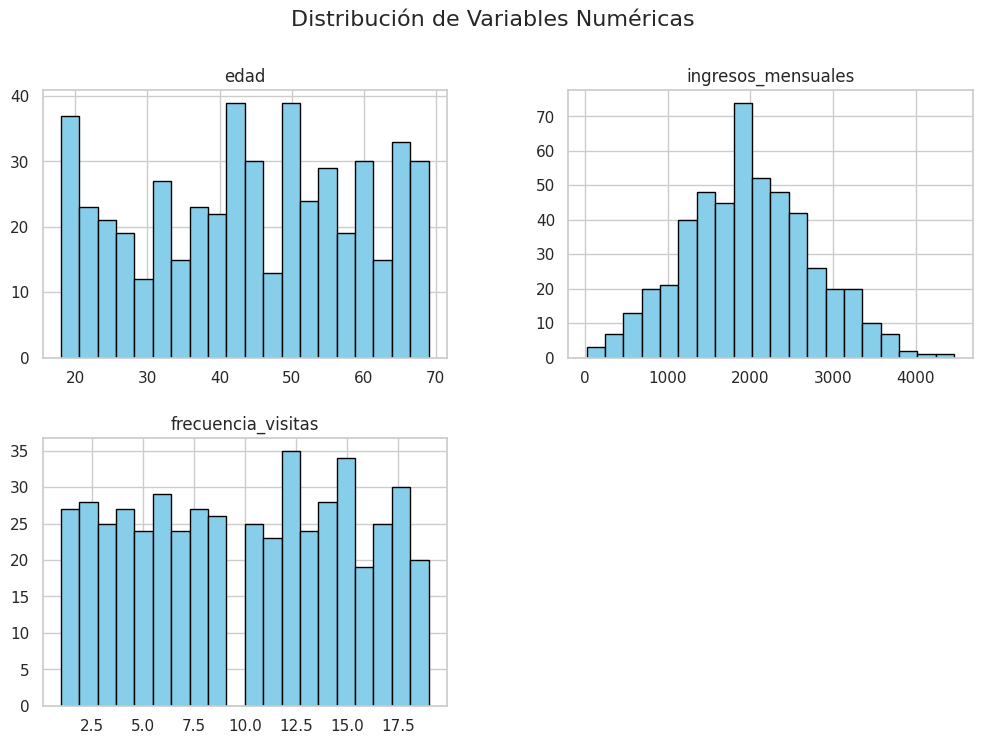

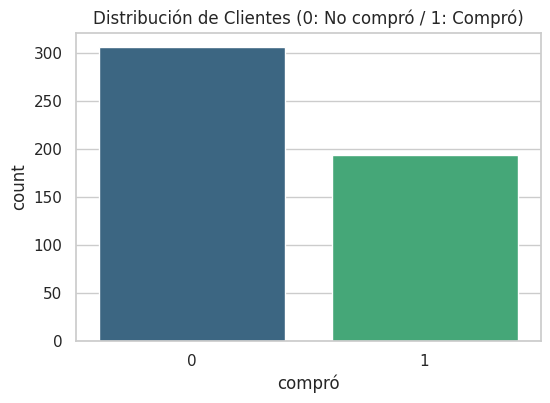

In [10]:
# Configuramos un estilo visual elegante para los gráficos
sns.set_theme(style="whitegrid")

# 1. Histogramas para ver cómo se distribuyen las edades, ingresos y visitas
columnas_num = ['edad', 'ingresos_mensuales', 'frecuencia_visitas']
df[columnas_num].hist(figsize=(12, 8), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas', fontsize=16)
plt.show()

# 2. Gráfico de barras para ver el balance de nuestra Variable Objetivo (Target)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='compró', hue='compró', palette='viridis', legend=False)
plt.title('Distribución de Clientes (0: No compró / 1: Compró)')
plt.show()

In [14]:
# Le decimos a Pandas que formatee la visualización de los decimales (float)
pd.set_option('display.float_format', '{:.2f}'.format)

In [15]:
from sklearn.preprocessing import StandardScaler

# 1. Convertir textos a números (One-Hot Encoding)
# Usamos drop_first=True para evitar información redundante
df_procesado = pd.get_dummies(df, columns=['region'], drop_first=True)

# 2. Igualar la escala de los números (Estandarización)
scaler = StandardScaler()
columnas_num = ['edad', 'ingresos_mensuales', 'frecuencia_visitas']
df_procesado[columnas_num] = scaler.fit_transform(df_procesado[columnas_num])

# Mostramos cómo quedó la tabla final
print("--- Así ve los datos la Inteligencia Artificial ---")
display(df_procesado.head())

--- Así ve los datos la Inteligencia Artificial ---


,customer_id,edad,ingresos_mensuales,frecuencia_visitas,compró,region_Norte,region_Oeste,region_Sur
0,1,0.78,2.24,-1.46,1,True,False,False
1,2,1.65,1.10,0.93,0,False,False,False
2,3,0.12,-1.57,0.75,0,False,False,False
3,4,-0.81,-0.49,0.20,0,False,True,False
4,5,1.05,1.34,-1.28,0,False,False,False


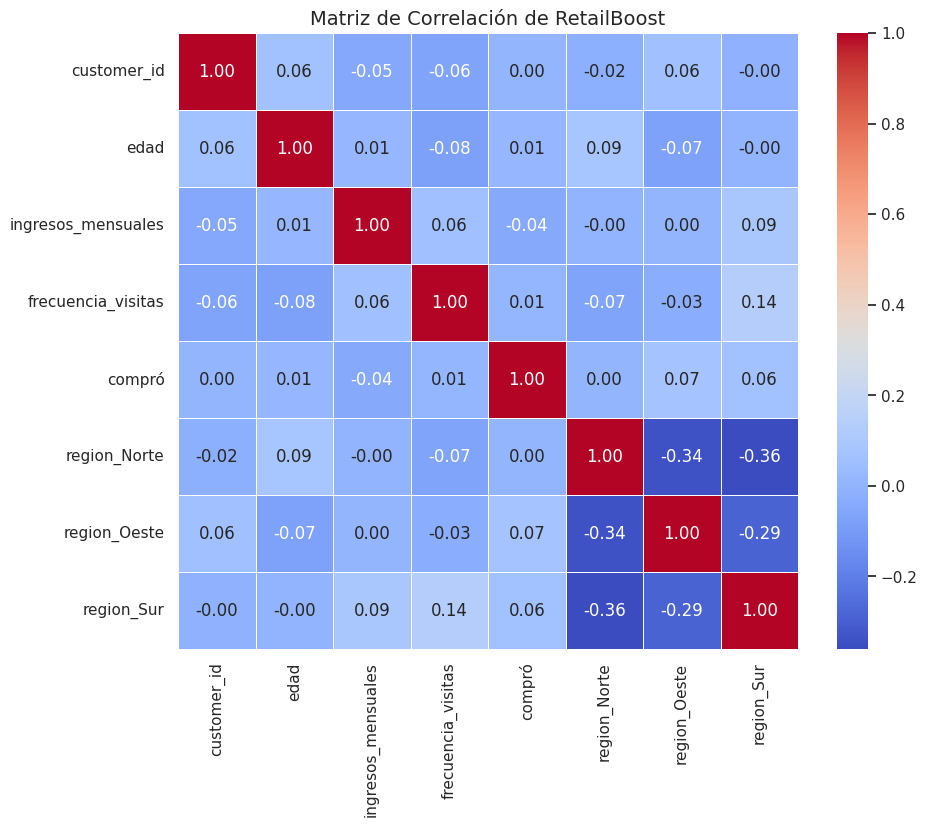


--- Importancia de cada variable para el modelo (Score) ---
Variable: edad                 | Puntaje: 0.10
Variable: ingresos_mensuales   | Puntaje: 0.86
Variable: frecuencia_visitas   | Puntaje: 0.03
Variable: region_Norte         | Puntaje: 0.00
Variable: region_Oeste         | Puntaje: 2.81
Variable: region_Sur           | Puntaje: 2.05


In [16]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Mapa de Calor (Heatmap) de Correlaciones
plt.figure(figsize=(10, 8))
matriz_corr = df_procesado.corr()
# annot=True pone los números dentro de los cuadraditos
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de RetailBoost', fontsize=14)
plt.show()

# 2. Selección automática de características
# Separamos las Features (X) de la variable Objetivo (y)
# OJO: Borramos el customer_id porque no sirve para predecir si alguien compra o no
X = df_procesado.drop(['compró', 'customer_id'], axis=1)
y = df_procesado['compró']

# Entrenamos al selector automático
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

print("\n--- Importancia de cada variable para el modelo (Score) ---")
# Imprimimos la nota que le puso el algoritmo a cada columna
for col, score in zip(X.columns, selector.scores_):
    print(f"Variable: {col:20} | Puntaje: {score:.2f}")

# 📊 Informe de Análisis Exploratorio (EDA) - RetailBoost
**Autor:** Julián Olivera | **Rol:** Data Scientist Junior

## 1. Limpieza y Preparación de Datos
Durante la carga inicial del dataset (500 registros), se detectaron dos anomalías críticas que fueron corregidas para garantizar la viabilidad del futuro modelo predictivo:
* **Valores Atípicos:** Se identificaron ingresos mensuales negativos (ej. -593.01), los cuales fueron catalogados como errores de carga y transformados a nulos.
* **Imputación de Nulos:** Se identificaron 15 registros vacíos. Las variables numéricas (`ingresos_mensuales`) fueron imputadas utilizando la **Mediana** (para evitar sesgos por sueldos extremos), y las categóricas (`region`) mediante la **Moda**.

## 2. Ingeniería de Características (Feature Engineering)
Para adecuar los datos a los algoritmos de Machine Learning, se aplicaron las siguientes transformaciones:
* **One-Hot Encoding:** Se digitalizó la variable categórica `region` en variables binarias (0 y 1), utilizando `drop_first=True` para evitar la multicolinealidad matemática.
* **Estandarización (StandardScaler):** Se unificó la escala de las variables numéricas (`edad`, `ingresos_mensuales` y `frecuencia_visitas`) para evitar que la magnitud de los sueldos opaque al resto de las variables por diferencia de tamaño.

## 3. Selección de Features y Conclusión Estratégica
A través del análisis de correlación (Heatmap) y el test estadístico automático `SelectKBest` (ANOVA), se determinó la importancia predictiva de cada variable respecto al target (`compró`).

**Hallazgos Principales:**
1. **La región es el factor determinante:** Las variables `region_Oeste` (Score: 2.81) y `region_Sur` (Score: 2.05) demostraron ser los mejores predictores de compra.
2. **Las visitas no aseguran conversión:** Sorprendentemente, la `frecuencia_visitas` obtuvo el puntaje más bajo (0.03), indicando que el tráfico web no se está traduciendo linealmente en ventas.
3. **Recomendación para el Modelo:** Para el entrenamiento del modelo de clasificación, se sugiere priorizar las variables de región y nivel de ingresos, y evaluar el descarte de la edad y la frecuencia de visitas para evitar introducir "ruido" al algoritmo.